# Supp Fig 6 — zero-shot to Visium / Visium HD / pseudo-Xenium

Reproduces **SuppFig6** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### SFig6 — setup & CONFIG
**🟡 moderate** · source: `pseudoV1_confusion_3panel.ipynb cell 2`

In [ ]:
from __future__ import annotations
import gc, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt

import spatnic
print('spatnic version =', spatnic.__version__)

# ============================================================
# CONFIG
# ============================================================
OUT_DIR = (COMP / 'pseudoV1_confusion').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Xenium (SPATNIC native test set) ---
XEN_H5AD = BENCHMARK_DB / 'adata_hvg_test.h5ad'

# --- Visium HD ---
HD_BINS_H5 = (VHD / 'Visium_HD_Human_Colon_Cancer_binned_outputs/binned_outputs/'
                    'square_016um/filtered_feature_bc_matrix.h5')
HD_PRED_CSV = COMP / 'visium_hd/visium_hd_16um_predictions.csv.gz'

# --- Visium V1/V2 (Valdeolivas 13 samples) ---
V1V2_SR_ROOT   = Path.home() / 'BICRC/data/valdeolivas_spaceranger'
V1V2_DSID_ROOT = Path.home() / 'BICRC/data'
V1V2_PRED_CSV  = COMP / 'visium_v1v2_groundtruth/per_spot_predictions.csv.gz'

V1V2_SAMPLES = {
    'SN048_A121573_Rep1':  {'source': 'spaceranger', 'path': 'SN048_A121573_Rep1'},
    'SN048_A121573_Rep2':  {'source': 'dsid',        'path': 'DSID001466'},
    'SN048_A416371_Rep1':  {'source': 'spaceranger', 'path': 'SN048_A416371_Rep1'},
    'SN048_A416371_Rep2':  {'source': 'spaceranger', 'path': 'SN048_A416371_Rep2'},
    'SN123_A551763_Rep1':  {'source': 'spaceranger', 'path': 'SN123_A551763_Rep1'},
    'SN123_A595688_Rep1':  {'source': 'dsid',        'path': 'DSID001470'},
    'SN123_A798015_Rep1':  {'source': 'spaceranger', 'path': 'SN123_A798015_Rep1'},
    'SN123_A938797_Rep1_X':{'source': 'spaceranger', 'path': 'SN123_A938797_Rep1_X'},
    'SN124_A595688_Rep2':  {'source': 'spaceranger', 'path': 'SN124_A595688_Rep2'},
    'SN124_A798015_Rep2':  {'source': 'dsid',        'path': 'DSID001475'},
    'SN124_A938797_Rep2':  {'source': 'dsid',        'path': 'DSID001476'},
    'SN84_A120838_Rep1':   {'source': 'spaceranger', 'path': 'SN84_A120838_Rep1'},
    'SN84_A120838_Rep2':   {'source': 'dsid',        'path': 'DSID001478'},
}

# --- V1 panel (Xenium V1 Human Colon CRC Add-on, 422 遺伝子) ---
V1_PANEL_H5AD = (BENCHMARK_DB / 'Xenium_CRC/'
                 'Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE_outs.h5ad')

MODEL = 'tumor_normal'

# --- palette (project: Tumor=#F4B183 / Normal=#9DC3E6) ---
LABEL_COLORS = {'Tumor': '#F4B183', 'Normal': '#9DC3E6'}

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'figure.dpi': 110,
})
warnings.filterwarnings('ignore', category=UserWarning)

# V1 panel gene set
V1_GENES = set(map(str, ad.read_h5ad(V1_PANEL_H5AD, backed='r').var_names))
print(f'V1 panel gene set: {len(V1_GENES)} genes')
print('OUT_DIR =', OUT_DIR)

### SFig6 — run_pseudoV1 / confusion helpers
**🟢 light (reads caches)** · source: `pseudoV1_confusion_3panel.ipynb cell 4`

In [ ]:
def run_pseudoV1(adata, label):
    """非 V1 遺伝子を 0 化して SPATNIC tumor_normal を実行。obs に予測列を追加して返す。"""
    a = adata.copy()
    xmax = float(a.X.max())
    if xmax > 25:
        sc.pp.normalize_total(a); sc.pp.log1p(a)
        print(f'  [{label}] raw counts (max={xmax:.0f}) -> normalize_total+log1p')
    mask = np.asarray(a.var_names.isin(V1_GENES))
    print(f'  [{label}] V1 panel ∩ data = {int(mask.sum()):,} / {a.n_vars:,} genes')
    if sp.issparse(a.X):
        a.X = (a.X.tocsr() @ sp.diags(mask.astype('float32'))).tocsr()
    else:
        a.X = a.X * mask[None, :]
    spatnic.predict(a, model=MODEL, key_added='spatnic_pred',
                    score_key_added='spatnic_score')
    return a.obs[['spatnic_pred', 'spatnic_score']].copy()


def confusion(gt_series, pred_series, labels=('Normal', 'Tumor')):
    """gt と pred の 2x2 (rows=gt, cols=pred) を返す。"""
    df = pd.DataFrame({'gt': gt_series.astype(str), 'pred': pred_series.astype(str)})
    df = df[df['gt'].isin(labels) & df['pred'].isin(labels)]
    cm = pd.crosstab(df['gt'], df['pred']).reindex(index=labels, columns=labels,
                                                    fill_value=0)
    return cm

### SFig6 — Xenium Pseudo-V1 prediction -> cm_xen
**🔴 heavy (GPU / multi-GB / long)** · source: `pseudoV1_confusion_3panel.ipynb cell 6`

In [ ]:
xen = sc.read_h5ad(XEN_H5AD)
print(f'Xenium test: {xen.n_obs:,} cells x {xen.n_vars:,} genes')
xen_pred = run_pseudoV1(xen, 'Xenium')
xen_pred['gt'] = xen.obs['Raw_annotation'].astype(str).values
cm_xen = confusion(xen_pred['gt'], xen_pred['spatnic_pred'])
print('\nXenium confusion (rows=GT, cols=Pseudo-V1):')
print(cm_xen.to_string())
xen_pred.to_csv(OUT_DIR / 'pseudoV1_xenium_predictions.csv.gz', compression='gzip')
del xen; gc.collect()

### SFig6 — Visium HD Pseudo-V1 prediction -> cm_hd
**🔴 heavy (GPU / multi-GB / long)** · source: `pseudoV1_confusion_3panel.ipynb cell 8`

In [ ]:
# --- Full SPATNIC 予測 (既存) を「GT 軸」として使用 ---
hd_full = pd.read_csv(HD_PRED_CSV, index_col=0)
print(f'HD existing predictions: {len(hd_full):,} bins  '
      f"(Full SPATNIC: {hd_full['spatnic_pred'].value_counts().to_dict()})")

# --- 16um bin の発現を h5 からロード、上皮 bin に絞る ---
hd = sc.read_10x_h5(str(HD_BINS_H5))
hd.var_names_make_unique()
print(f'HD raw 16um: {hd.n_obs:,} bins x {hd.n_vars:,} genes')

keep_bc = hd.obs_names.intersection(hd_full.index)
hd_sub = hd[keep_bc].copy()
print(f'epithelium bins (matched with full predictions): {hd_sub.n_obs:,}')

# --- Pseudo-V1 ---
hd_pred = run_pseudoV1(hd_sub, 'Visium HD')
# join with full
hd_pred['gt'] = hd_full.loc[hd_pred.index, 'spatnic_pred'].astype(str).values  # ← Full SPATNIC が GT 軸
cm_hd = confusion(hd_pred['gt'], hd_pred['spatnic_pred'])
print('\nVisium HD confusion (rows=Full SPATNIC, cols=Pseudo-V1):')
print(cm_hd.to_string())
hd_pred.to_csv(OUT_DIR / 'pseudoV1_visium_hd_predictions.csv.gz', compression='gzip')
del hd, hd_sub; gc.collect()

### SFig6 — Visium V1/V2 Pseudo-V1 prediction -> cm_v1v2
**🔴 heavy (GPU / multi-GB / long)** · source: `pseudoV1_confusion_3panel.ipynb cell 10`

In [ ]:
def _load_v1v2(sid, info):
    if info['source'] == 'dsid':
        mtx_dir = V1V2_DSID_ROOT / info['path']
    else:
        mtx_dir = V1V2_SR_ROOT / info['path'] / 'filtered_feature_bc_matrix'
    a = sc.read_10x_mtx(str(mtx_dir), var_names='gene_symbols', make_unique=True)
    return a


vp = pd.read_csv(V1V2_PRED_CSV)
print(f'V1/V2 per_spot CSV: {len(vp):,} rows over {vp["sample"].nunique()} samples')

# サンプル別にループ
v1v2_pred_rows = []
for sid in sorted(V1V2_SAMPLES):
    info = V1V2_SAMPLES[sid]
    sample_rows = vp[vp['sample'] == sid]
    if sample_rows.empty:
        print(f'  [skip] {sid}: per_spot CSV に該当行なし')
        continue
    try:
        a = _load_v1v2(sid, info)
    except Exception as e:
        print(f'  [skip] {sid}: load failed: {e}')
        continue
    keep_bc = a.obs_names.intersection(sample_rows['barcode'])
    if len(keep_bc) == 0:
        print(f'  [skip] {sid}: barcode 一致なし'); continue
    a_sub = a[keep_bc].copy()
    print(f'\n=== {sid} ({len(keep_bc):,} spots) ===')
    pred = run_pseudoV1(a_sub, sid)
    pred['sample'] = sid
    v1v2_pred_rows.append(pred.reset_index().rename(columns={'index':'barcode'}))
    del a, a_sub; gc.collect()

v1v2_pred = pd.concat(v1v2_pred_rows, ignore_index=True)
print(f'\nV1/V2 Pseudo-V1 predictions: {len(v1v2_pred):,} spots')

# GT (gt_label) を join
v1v2_pred = v1v2_pred.merge(vp[['barcode', 'sample', 'gt_label']],
                            on=['barcode', 'sample'], how='left')
cm_v1v2 = confusion(v1v2_pred['gt_label'], v1v2_pred['spatnic_pred'])
print('\nVisium V1/V2 confusion (rows=Pathologist GT, cols=Pseudo-V1):')
print(cm_v1v2.to_string())
v1v2_pred.to_csv(OUT_DIR / 'pseudoV1_visium_v1v2_predictions.csv.gz',
                 index=False, compression='gzip')

### Supp Fig 6 — pseudo-panel confusion (3 platforms)
**🟢 light (reads caches)** · source: `pseudoV1_confusion_3panel.ipynb cell 12`

In [ ]:
def plot_cm(ax, cm, title, xlabel, ylabel,
            cell_fs=18, tick_fs=14, label_fs=14, title_fs=15):
    cm = cm.astype(float)
    cmn = cm.values / cm.values.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f'{int(cm.values[i,j]):,}\n({cmn[i,j]:.2f})',
                    ha='center', va='center', fontsize=cell_fs, fontweight='bold',
                    color='white' if cmn[i,j] > 0.5 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(cm.columns, fontsize=tick_fs)
    ax.set_yticks([0, 1]); ax.set_yticklabels(cm.index, fontsize=tick_fs)
    ax.set_xlabel(xlabel, fontsize=label_fs)
    ax.set_ylabel(ylabel, fontsize=label_fs)
    ax.set_title(title, fontsize=title_fs, fontweight='bold')
    return im


# パネル順: Visium HD | Visium V1/V2 | Xenium  (Xenium を一番右に)
fig, axes = plt.subplots(1, 3, figsize=(19, 6.6), dpi=130)

plot_cm(axes[0], cm_hd,
        f'Visium HD  (n={int(cm_hd.values.sum()):,})',
        'Pseudo-V1 pred', 'Full SPATNIC (reference)')
plot_cm(axes[1], cm_v1v2,
        f'Visium V1/V2  (n={int(cm_v1v2.values.sum()):,})',
        'Pseudo-V1 pred', 'Pathologist GT')
plot_cm(axes[2], cm_xen,
        f'Xenium  (n={int(cm_xen.values.sum()):,})',
        'Pseudo-V1 pred', 'Raw_annotation (GT)')

fig.suptitle('Pseudo-V1 SPATNIC tumor_normal — confusion matrices (row-normalized)',
             fontsize=17, fontweight='bold', y=1.02)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f'pseudoV1_confusion_3panel.{ext}')
plt.show()

# 数値サマリも csv で保存 (figure と同じ並び順)
summary_rows = []
for name, cm, axis in [('Visium HD',    cm_hd,   'Full SPATNIC (reference)'),
                        ('Visium V1/V2', cm_v1v2, 'Pathologist GT'),
                        ('Xenium',       cm_xen,  'Raw_annotation (GT)')]:
    tn, fp = int(cm.iloc[0, 0]), int(cm.iloc[0, 1])
    fn, tp = int(cm.iloc[1, 0]), int(cm.iloc[1, 1])
    sens = tp / max(1, tp+fn); spec = tn / max(1, tn+fp); acc = (tp+tn)/max(1,tp+tn+fp+fn)
    summary_rows.append(dict(platform=name, axis=axis, TN=tn, FP=fp, FN=fn, TP=tp,
                             sensitivity=sens, specificity=spec, accuracy=acc,
                             balanced_acc=0.5*(sens+spec), n=tp+tn+fp+fn))
summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT_DIR / 'pseudoV1_confusion_summary.csv', index=False)
print('\n=== summary ==='); print(summary.round(4).to_string(index=False))

## Published result (reference)
Embedded reference output; the code above regenerates it.

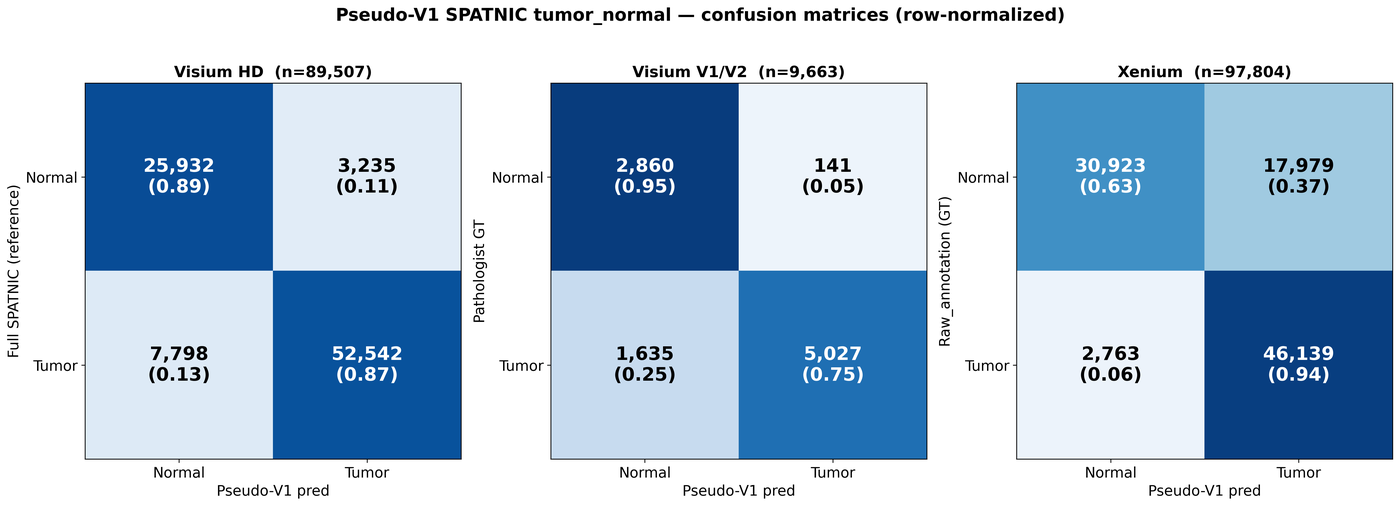

In [ ]:
# Pseudo-panel confusion (3 platforms)
Image(str(COMP / "pseudoV1_confusion/pseudoV1_confusion_3panel.png"))